In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

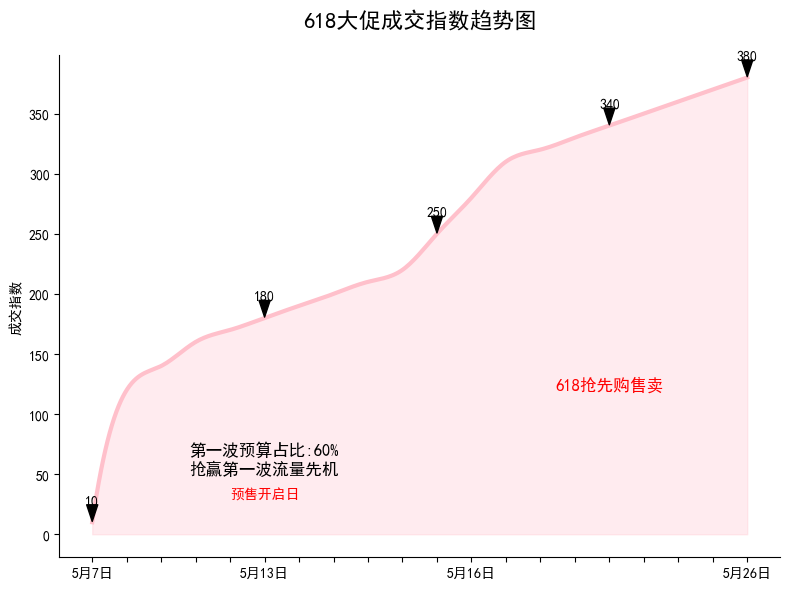

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# 日期数据，用序号代表日期（5月7日为第0天，后续依次类推）
x = np.arange(0, 20, 1)
# 模拟成交指数数据，大致模拟原曲线趋势
y = [10, 120, 140, 160, 170, 180, 190, 200, 210, 220, 250, 280, 310, 320, 330, 340, 350, 360, 370, 380]

# 创建更密集的x轴数据点，用于平滑曲线
x_smooth = np.linspace(x.min(), x.max(), 300)

# 使用三次样条插值创建平滑曲线
spl = make_interp_spline(x, y, k=3)  # k=3表示三次样条
y_smooth = spl(x_smooth)

# 创建画布
fig, ax = plt.subplots(figsize=(8, 6))

# 添加主标题
plt.title('618大促成交指数趋势图', fontsize=16, pad=20)

# 绘制平滑曲线，设置颜色接近原图表的渐变
line, = ax.plot(x_smooth, y_smooth, color='pink', linewidth=3)
# 给曲线下方填充渐变颜色
ax.fill_between(x_smooth, y_smooth, color='pink', alpha=0.3)

# 设置 x 轴刻度和标签，对应实际日期
x_labels = ['5月7日', '', '', '', '', '5月13日', '', '', '', '', '', '5月16日', '', '', '', '', '', '', '', '5月26日']
ax.set_xticks(np.arange(0, 20, 1))
ax.set_xticklabels(x_labels, rotation=0, ha='center')

# 添加标注文本
ax.text(5, 50, '第一波预算占比:60%\n抢赢第一波流量先机', fontsize=12, ha='center')
ax.text(5, 30, '预售开启日', fontsize=10, ha='center', color='red')
ax.text(15, 120, '618抢先购售卖', fontsize=12, ha='center', color='red')

# 标注关键数据点
highlight_indices = [0, 5, 10, 15, 19]  # 选择要标注的数据点索引
for i in highlight_indices:
    # 在原始数据点位置标注，而非平滑后的位置
    ax.annotate(f'{y[i]}',  # 标注的文本内容
                xy=(x[i], y[i]),  # 要标注的数据点
                xytext=(x[i], y[i]+15),  # 文本位置（数据点上方）
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),  # 箭头样式
                ha='center',  # 水平对齐方式
                fontsize=10)  # 字体大小

# 设置 y 轴标签
ax.set_ylabel('成交指数')

# 隐藏顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 显示图表
plt.tight_layout()
plt.show()

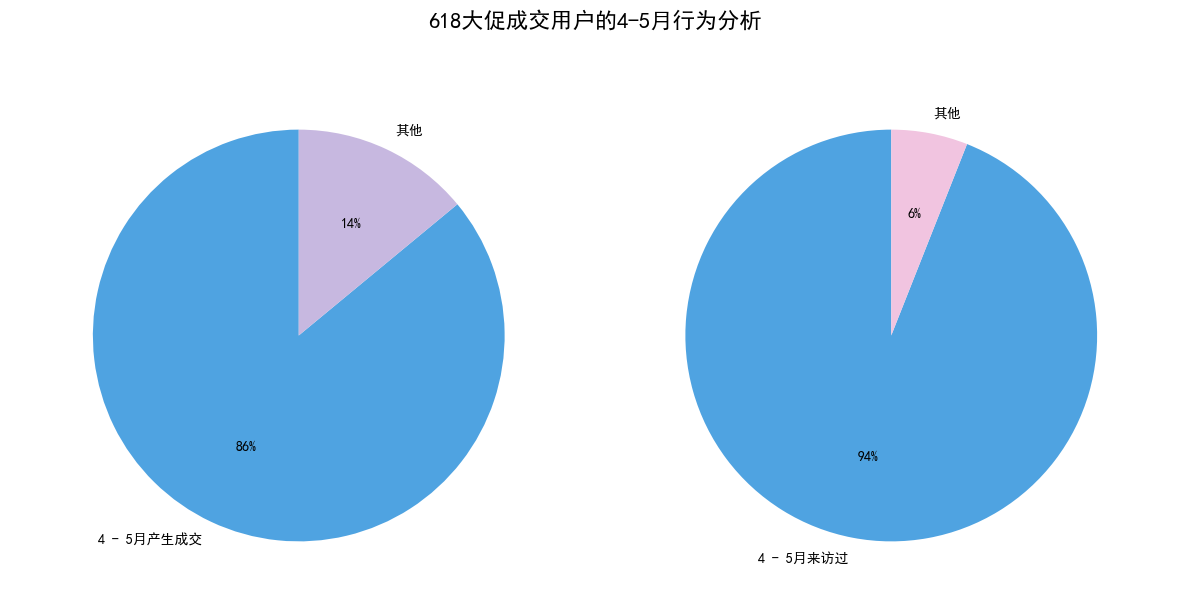

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 第一个饼图数据
labels_1 = ['4 - 5月产生成交', '其他']
sizes_1 = [86, 14]  # 数据大体一致，总和为100
colors_1 = ['#4fa3e1', '#c7b8e0']  # 颜色接近原图

# 第二个饼图数据
labels_2 = ['4 - 5月来访过', '其他']
sizes_2 = [94, 6]  # 数据大体一致，总和为100
colors_2 = ['#4fa3e1', '#f1c4e0']  # 颜色接近原图

# 创建画布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# 设置整体标题
fig.suptitle('618大促成交用户的4-5月行为分析', fontsize=16, fontweight='bold')

# 绘制第一个饼图
ax1.pie(sizes_1, labels=labels_1, autopct='%1.0f%%', startangle=90, colors=colors_1)

# 绘制第二个饼图
ax2.pie(sizes_2, labels=labels_2, autopct='%1.0f%%', startangle=90, colors=colors_2)

# 让饼图显示为正圆形
for ax in [ax1, ax2]:
    ax.axis('equal')

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # 调整子图与顶部的距离
plt.show()

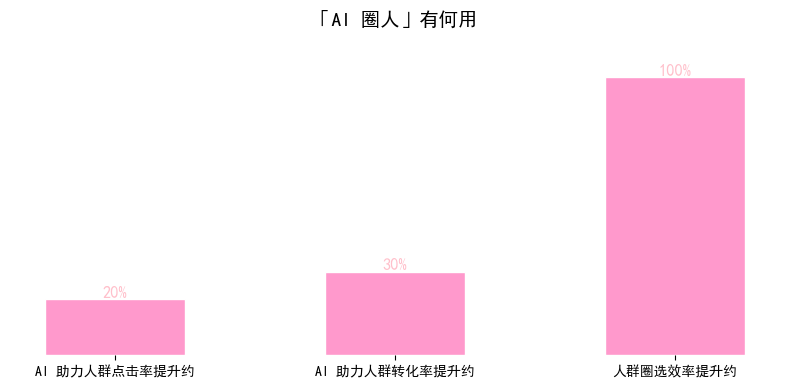

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ["AI 助力人群点击率提升约", "AI 助力人群转化率提升约", "人群圈选效率提升约"]
values = [20, 30, 100]  # 百分比数值
colors = ["#FF99CC", "#FF99CC", "#FF99CC"]  # 接近的粉色
bar_width = 0.5  # 柱状图宽度
x = np.arange(len(labels))  # x 轴位置

# 创建图形
fig, ax = plt.subplots(figsize=(8, 4))  # 调整画布大小，接近原图表比例

# 绘制柱状图
bars = ax.bar(x, values, width=bar_width, color=colors, edgecolor="white")

# 添加标题
ax.set_title("「AI 圈人」有何用", fontsize=14, fontweight="bold", y=1.1)  # 标题位置稍上

# 添加数据标签
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{value}%",
            ha="center", va="bottom", fontsize=12, color="pink")

# 设置 x 轴刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)

# 隐藏 y 轴（原图表无 y 轴显示）
ax.yaxis.set_visible(False)

# 隐藏边框（更接近原图表简洁风格）
for spine in ax.spines.values():
    spine.set_visible(False)

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()